In [1]:
import numpy as np
import pandas as pd
import os
import sys
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import country_converter as coco
import geopandas as gpd

parent_dir = os.path.abspath("..")
sys.path.insert(0, parent_dir)

import numpy as np
import pandas as pd

from experiments import utils
from package_name.model.utils import sampling, LossFactorsConfig
from package_name.training.trainer import VAETrainer, VAEConfig
from package_name.tuning.cross_validator import CrossValidator
from package_name.inference.predictor import VAEPredictor

import matplotlib.pyplot as plt
import plotly.express as px
plt.style.use("dark_background")



/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
I0000 00:00:1783003347.528629 2400113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783003347.529692 2400113 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783003347.601072 2400113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783003351.985322 2400113 port.cc:153] oneDNN custom operations are on. You ma

## Parameters

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
filepath = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/"
cluster_number = 4
original_dim = 575
pr_cluster_number = 4
batch_size = 128
epochs = 500


## Data loading and pre-processing

In [8]:
# Get training data
z500 = utils.preprocess_dataset(filename ='/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/z500/era5_z500_daily_250_atlantic_1940_2022.nc',
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'extended europe',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)

# Get training data labels
pr_labels = pd.read_csv('/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/WON_clusters_norm.csv')
pr_labels.columns = ['index', 'labels']
#pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

In [ ]:
#create clusters for country-wise energy data
path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/WON_country_wise.csv"

df_in = pd.read_csv(path, comment="#")

df_filtered = df_in.copy()
df_filtered["Date"] = pd.to_datetime(df_filtered["Date"])
df_filtered = df_filtered[(df_filtered["Date"].dt.year > 1980) & (df_filtered["Date"].dt.year < 2023)]
df_filtered = df_filtered[df_filtered["Date"].dt.month.isin(extended_winter_months)]

df_countries = df_filtered.drop(columns=["Date"])
df_countries = df_countries.dropna(axis=1, how="all").reset_index(drop=True)

df_norm, df_clusters = utils.cluster_country_wise(df_countries, cluster_number=pr_cluster_number, standardize=True)

#df_clusters.to_csv("/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/WON_clusters_norm.csv")
#df_norm.to_csv("/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/WON_country_wise_norm.csv")

In [5]:
#count the number of samples in each cluster and print it
print(df_clusters["labels"].value_counts())

labels
1    2453
0    1469
3    1362
2    1068
Name: count, dtype: int64


## Visualise target clusters

In [5]:
#select days belonging to each cluster and calculate the mean of each cluster and put into df_cluster_means
df_cluster_means = pd.DataFrame(columns=df_norm.columns)
for i in range(4):
    cluster_i = df_norm[df_clusters["labels"] == i]
    cluster_i_mean = cluster_i.mean()
    df_cluster_means.loc[i] = cluster_i_mean

In [23]:
# TODO: turn this into a function
column_labels = df_norm.columns.astype(str).tolist()

plot_data_list = []
for cluster_id in range(4):
    df_temp = pd.DataFrame({
        'iso2_labels': column_labels,  
        'metric_value': df_cluster_means.loc[cluster_id].values,
        'cluster': f"K-means Cluster {cluster_id}" 
    })
    plot_data_list.append(df_temp)

df_plot = pd.concat(plot_data_list, ignore_index=True)

# Convert the ISO-2 labels column to ISO-3 strings
cc = coco.CountryConverter()
df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

# Plot
fig = px.choropleth(
    df_plot,
    locations="iso3_labels",        
    locationmode="ISO-3",         
    color="metric_value",         
    hover_name="iso2_labels",    
    scope="europe",               
    facet_col="cluster",         
    color_continuous_scale=px.colors.sequential.Viridis, 
    title="European Energy Clusters"
)


fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) # Removes ugly "cluster=" prefix from subplot titles
fig.update_layout(
    margin={"r":10, "t":40, "l":10, "b":5},
    height=200, 
    width=600, 

    coloraxis_colorbar=dict(
        title="Wind CF anomaly",     
        thicknessmode="pixels",
        thickness=5,  
        orientation="h",          
        lenmode="fraction",
        len=0.5,              
        yanchor="middle",       
        y=-0.1
    )
)

fig.show()

## Define model

In [22]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,#8,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

loss_config = LossFactorsConfig(
    vae_reconstruction_loss_factor=1,
    vae_regularisation_loss_factor=1,
    target_prediction_loss_factor=1,
    cluster_target_regularisation_loss_factor=1,#5
    mixture_regularization_loss_factor=1,#2,
    dirichlet_loss_factor=0.5,#1
)

vae = VAETrainer(cfg=config,  path_to_save_weights=filepath, loss_factors=loss_config)
vae.compile()

history = vae.fit(
    X=z500.values,
    y=label_indices,
    epochs=epochs,
    batch_size=batch_size
)

vae.save_weights(filepath+'final_weights_'+str(cluster_number)+'.weights.h5')

Epoch 1/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - cluster_target_regularisation_loss: 0.2211 - mixture_regularization_loss: 3.3733 - reconstruction_loss: 479.6465 - target_prediction_loss: 6.1338 - total_loss: 502.5388 - vae_regularisation_loss: 13.1643 - val_cluster_target_regularisation_loss: 0.3391 - val_mixture_regularization_loss: 3.2067 - val_reconstruction_loss: 302.4310 - val_target_prediction_loss: 6.5532 - val_total_loss: 338.4576 - val_vae_regularisation_loss: 25.9276
Epoch 2/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - cluster_target_regularisation_loss: 0.2769 - mixture_regularization_loss: 3.1368 - reconstruction_loss: 252.6572 - target_prediction_loss: 5.9535 - total_loss: 283.4881 - vae_regularisation_loss: 21.4637 - val_cluster_target_regularisation_loss: 0.2449 - val_mixture_regularization_loss: 3.0727 - val_reconstruction_loss: 233.7045 - val_target_prediction_loss: 5.6771 - val_total_loss: 261.3667 - val_vae_regularisation_loss: 18.6676
Epoch 3/500
35/35 ━━━━━━

## Plot training and validation losses

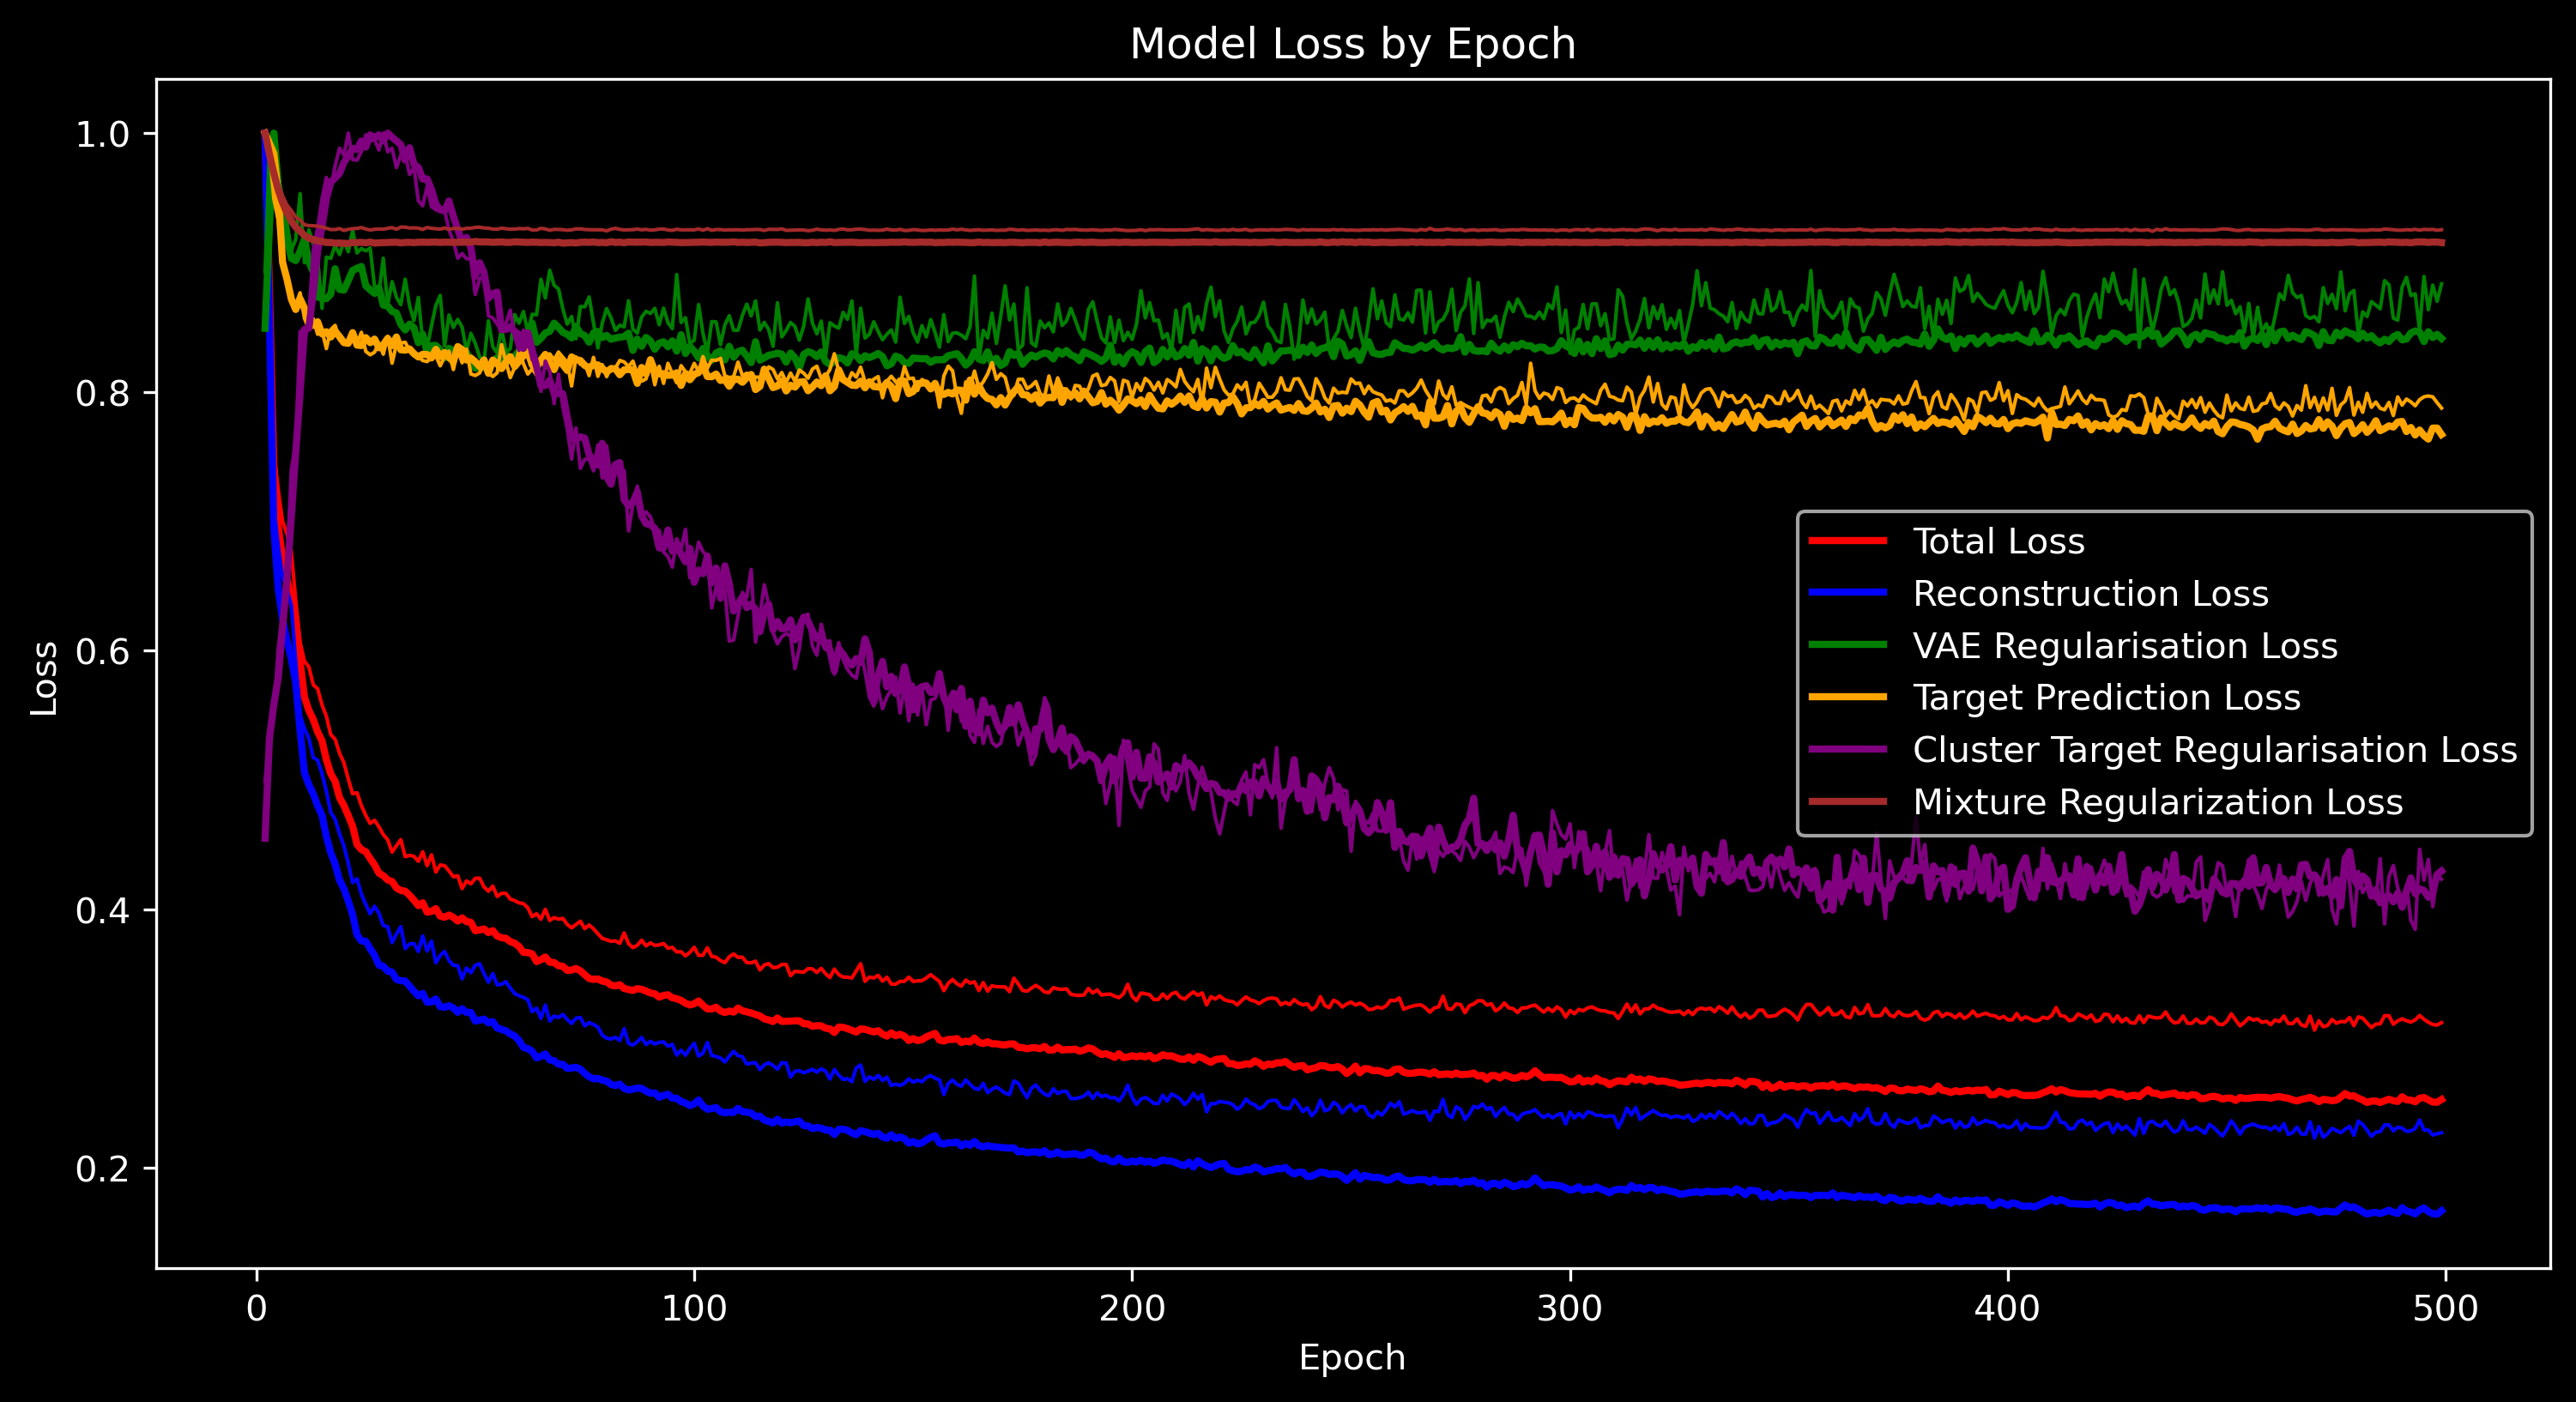

In [24]:
utils.plot_all_losses(history=history)

## Cross validation

In [10]:
cross_validator = CrossValidator(vae=vae,filepath=filepath,cluster_number=cluster_number,n_runs=3)
histories = cross_validator.run(X=z500.values,y=label_indices,epochs=epochs, batch_size=batch_size)

/home/zilnora/.conda/envs/CodeForEarth/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - cluster_target_regularisation_loss: 0.2251 - mixture_regularization_loss: 2.9900 - reconstruction_loss: 486.2545 - target_prediction_loss: 5.8071 - total_loss: 507.7526 - vae_regularisation_loss: 12.4760 - val_cluster_target_regularisation_loss: 0.3383 - val_mixture_regularization_loss: 2.9028 - val_reconstruction_loss: 328.1687 - val_target_prediction_loss: 5.9310 - val_total_loss: 357.9712 - val_vae_regularisation_loss: 20.6304
Epoch 2/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - cluster_target_regularisation_loss: 0.3553 - mixture_regularization_loss: 2.8777 - reconstruction_loss: 260.4190 - target_prediction_loss: 5.9380 - total_loss: 291.6782 - vae_regularisation_loss: 22.0881 - val_cluster_target_regularisation_loss: 0.3822 - val_mixture_regularization_loss: 2.8147 - val_reconstruction_loss: 228.8544 - val_target_prediction_loss: 5.7116 - val_total_loss: 260.4668 - val_vae_regularisation_loss: 22.7039
Epoch 3/500
35/35 ━━━━━━

KeyboardInterrupt: 

In [11]:
number = 1

training_loss = histories[number].history['total_loss']
validation_loss = histories[number].history['val_total_loss']
utils.plot_losses(training_loss, validation_loss)

NameError: name 'histories' is not defined

## Visualize the clusters

In [25]:
cluster_number = 4

config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

vae = VAEPredictor(cfg=config)
#vae.load_weights(filepath+'final_weights_'+str(cluster_number)+'_'+str(0)+'.weights.h5')
vae.load_weights(filepath+'final_weights_'+str(cluster_number)+'.weights.h5')

In [26]:
X_all = z500.values.reshape(z500.values.shape[0], -1, order='F')
input = {
    "x": X_all,
    "dummy": np.ones((X_all.shape[0], 1)),
    "target": np.zeros((X_all.shape[0], vae.cfg.pr_cluster_number)),
}

In [27]:
encoded = vae.encode(input, batch_size=batch_size)
cluster_probs = encoded['clusters']['clusters_pred']
cluster_label = np.argmax(cluster_probs, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [28]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

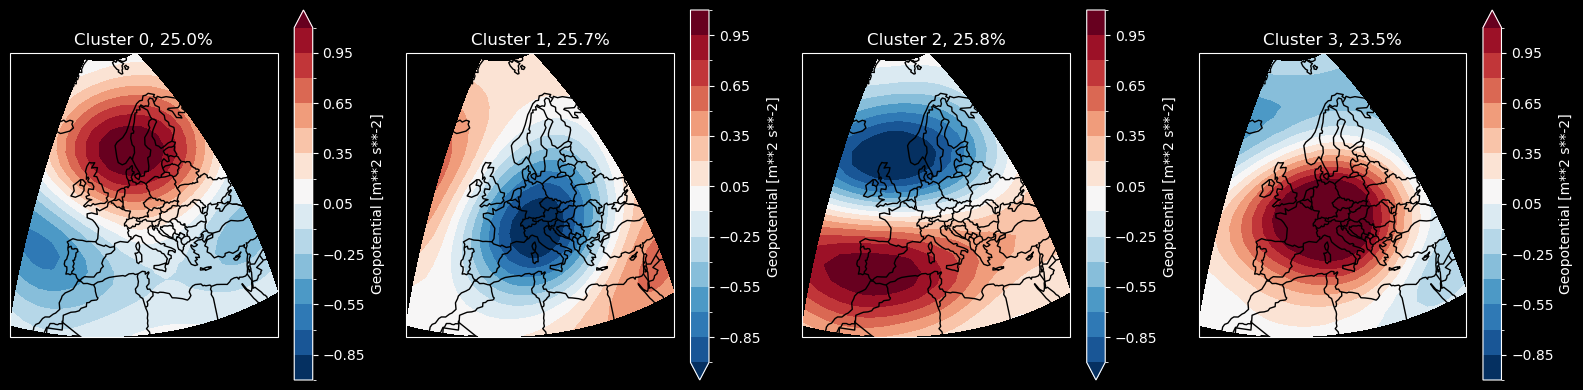

In [21]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

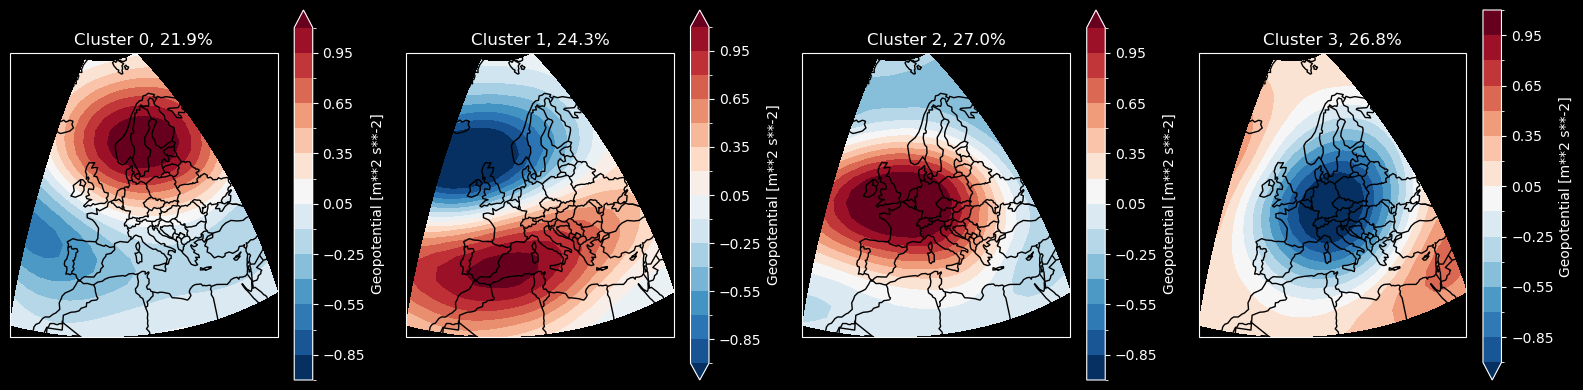

In [18]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

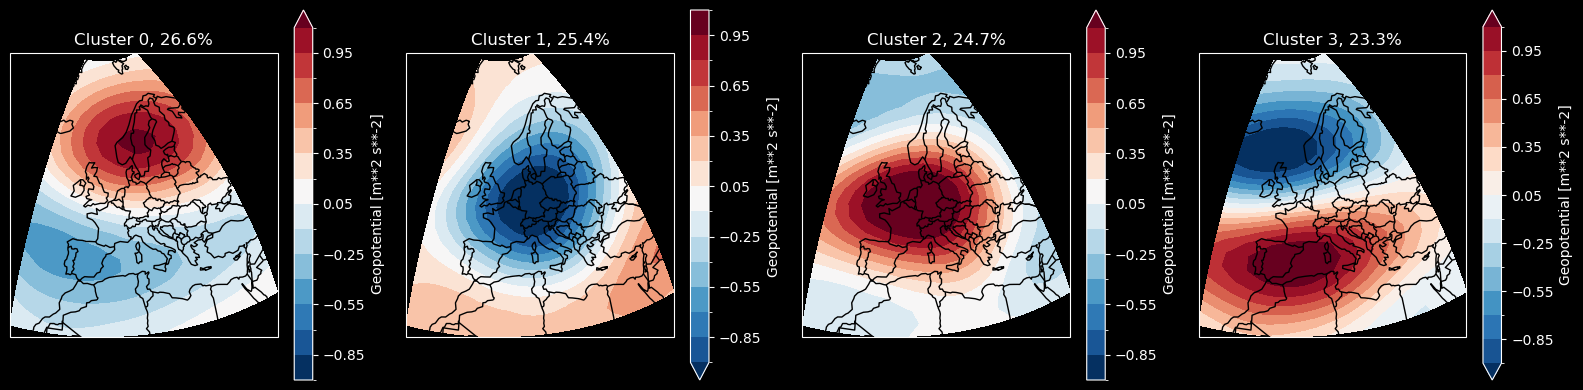

In [29]:
z500_with_label = z500.assign_coords(label=("time", cluster_label))
cluster_centers_empirical = z500_with_label.groupby("label").mean()

#order clusters by how often they occur in the data
label_counts = np.bincount(z500_with_label.label.values)
label_order = np.argsort(label_counts)[::-1]  # Sort in descending order


### Keep the same training / testing sets
utils.plot_cluster_centers(cluster_centers_empirical,
                           z500_with_label.label.values,
                           levels=np.arange(-1., 1.1, 0.15))

In [30]:
wind_energy_means = df_norm.groupby(z500_with_label.label.values).mean()

In [31]:
column_labels = df_norm.columns.astype(str).tolist()

plot_data_list = []
for cluster_id in range(cluster_number):
    df_temp = pd.DataFrame({
        'iso2_labels': column_labels,  
        'metric_value': wind_energy_means.loc[cluster_id].values,
        'cluster': f"Regime {cluster_id}" 
    })
    plot_data_list.append(df_temp)

df_plot = pd.concat(plot_data_list, ignore_index=True)

cc = coco.CountryConverter()

# Convert the ISO-2 labels column to ISO-3 strings
df_plot['iso3_labels'] = cc.convert(names=df_plot['iso2_labels'].tolist(), to='ISO3')

# Plot
fig = px.choropleth(
    df_plot,
    locations="iso3_labels",        
    locationmode="ISO-3",         
    color="metric_value",         
    hover_name="iso2_labels",    
    scope="europe",               
    facet_col="cluster",         
    color_continuous_scale=px.colors.sequential.Viridis, 
    title="Wind CF Clusters"
)


fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1])) 
fig.update_layout(
    margin={"r":10, "t":40, "l":10, "b":5},
    height=200, 
    width=600, 

    coloraxis_colorbar=dict(
        title="Wind CF anomaly",     # Label for the scale
        thicknessmode="pixels",
        thickness=5,  
        orientation="h",           # Thinner bar (default is usually 30)
        lenmode="fraction",
        len=0.5,                  # Takes up only 60% of the map height instead of 100%
        yanchor="middle",         # Centers it vertically
        y=-0.1
    )
)

fig.show()

## Evaluate clusters